In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [24]:
import numpy as np
import cuml
import cupy as cp
import matplotlib.pyplot as plt
import cudf
import datasets

In [26]:
ds = datasets.load_dataset("iitolstykh/LLMTrace_classification")
y_train = [0 if label == 'ai' else 1 for label in ds['train']['label']]

In [4]:
X_train = np.load('/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_train.npy')
norm = np.linalg.norm(X_train, axis=1, keepdims=True)
X_train /= norm
X_train.mean(axis=1), X_train.var(axis=1)

(array([-4.780e-05, -4.196e-05, -1.956e-04, ..., -9.960e-05,  2.408e-05,
        -1.633e-04], dtype=float16),
 array([0.001302, 0.001302, 0.001302, ..., 0.001302, 0.001304, 0.001302],
       dtype=float16))

In [6]:
X_train_cupy = cp.array(X_train)

Text(0.5, 1.0, 'Визуализация полученных эмбеддингов текстов с помощью PCA')

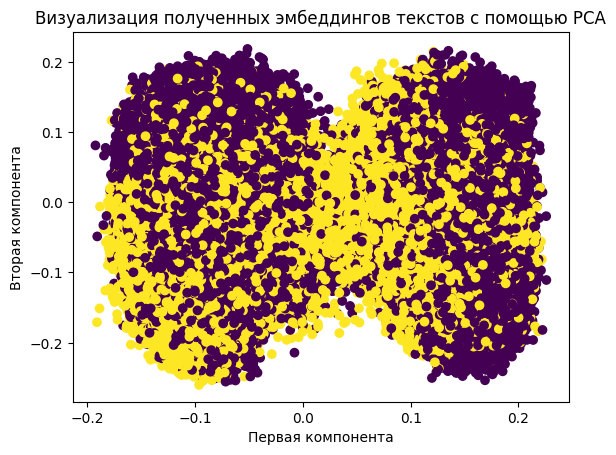

In [28]:
pca = cuml.decomposition.PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_cupy)
# print(X_train_pca[:, 0])
# print(X_train_pca[:, 1])



/tmp/ipykernel_55/4225205255.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


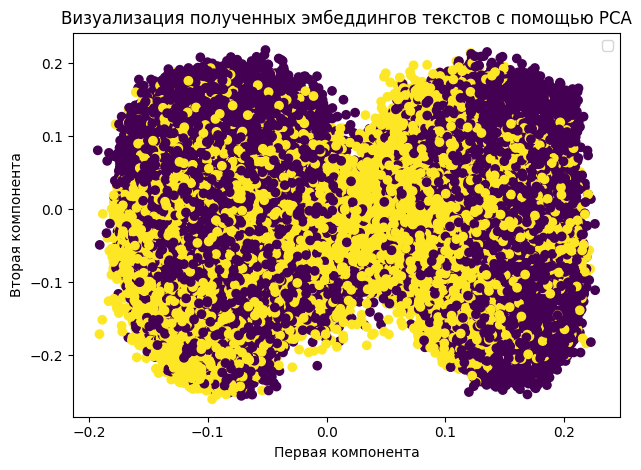

In [29]:
plt.scatter(X_train_pca.get()[:, 0], X_train_pca.get()[:, 1], c=y_train)
plt.xlabel('Первая компонента')
plt.ylabel('Вторая компонента')
plt.title('Визуализация полученных эмбеддингов текстов с помощью PCA')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
from cuml import LogisticRegression

In [32]:
y_train = cp.array(y_train)

lr = LogisticRegression(max_iter=2500)
lr.fit(X_train, y_train)

LogisticRegression()

In [36]:
X_test = cp.load('/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_test.npy')
y_test = cp.array([0 if label == 'ai' else 1 for label in ds['test']['label']])

In [37]:
preds = lr.predict(X_test)

In [38]:
from sklearn.metrics import classification_report
print(classification_report(y_test.get(), preds.get()))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86     54484
           1       0.80      0.79      0.79     36466

    accuracy                           0.84     90950
   macro avg       0.83      0.83      0.83     90950
weighted avg       0.84      0.84      0.84     90950



In [ ]:
#TODO: откалибровать модель 